# POC 1 - Chirplet Generation Exploration

The purpose of this notebook is to explore the two proposed methods for parameterized chirplet kernel generation. The first step of the audio frontend (AFE) is referred to as PPCF, or Partial Polynomial Chirplet Filtering/Filterbank, a learnable set of chirplet filters to exract relevant spectrotemporal content for spoof detection. The filterbank is "partial" because there's no structured characterization of the input signal's frequency content, as there would be in e.g. a DFT. "Polynomial" is the means by which the bases/kernels are created, such that the instantaneous frequency is parameterized polynomially. "Chirplet" is a swept sinusoid, a set of which will be used as filters on the input signal to produce the PPCF output channels.

The two proposed methods for parameterized chirplet kernel generation are as follows:

**1. Simple / Single Term**
The kernel of duration T is a swept sine of frequency range f_1 to f_2, with instantaneous frequency f_i controlled by a single term polynomial function of degree p, such that f_i is monotonically increasing or decreasing.

**2. Complex / Multi Term**
The kernel of duration T is a swept sine of frequency range f_1 to f_2 with f_i controlled by a multi term polynomial - Bezier Curve. 

Below, chirplets will be created and analyzed with a focus on Method 1 for POC

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as cti
from math import factorial as fact

# Inline plotting
%matplotlib widget

In [2]:
# Constants

FS = 16000 # samplerate

## Single Term Polynomial Chirplet

In [3]:
# pchirp - single term polynomial chirplet
def pchirp(freq1, freq2, duration_ms, degree):
    """
    """

    # Time vector
    T = duration_ms / 1000.
    t = np.arange(0., T, 1. / FS)

    # Inst freq
    f_i = freq1 + (freq2 - freq1) * (t / T) ** degree

    # # Check inst freq
    # plt.figure()
    # plt.plot(t * 1000, f_i)
    # plt.title('Single')

    # Inst phase
    phi_i = 2 * np.pi * cti(f_i, t, initial=0)

    return np.sin(phi_i) * np.hanning(len(phi_i))

## Multi Term Polynomial Chirplet

In [4]:
# # pchirpm - multi term polynomial chirplet - fixed degrees based on number of 

# # Precompute factorials
# facts = {i: fact(i) for i in range(15)}
# def pchirpm(duration_ms, ctrl_points):
#     """
#     ctrl_points length determines number of terms and degree (n = len(ctrl_points - 1)]
#     """

#     # Time vector
#     T = duration_ms / 1000.
#     t = np.arange(0., T, 1. / FS)

#     # Inst freq
#     f_i = np.zeros_like(t)
#     u = t / T
#     n = len(ctrl_points) - 1
#     for i in range(len(ctrl_points)):
#         fac_i = facts[n] / facts[i] / facts[n - i]
#         B_in = fac_i * u**i * (1 - u)**(n - i)
#         f_i += ctrl_points[i] * B_in
        

#     # # Check inst freq
#     # plt.figure()
#     # plt.plot(t * 1000, f_i)
#     # plt.ylim(f1*0.8, f2*1.2)
#     # plt.title('Multi')

#     # Inst phase
#     phi_i = 2 * np.pi * cti(f_i, t, initial=0)

#     return np.sin(phi_i) * np.hanning(len(phi_i))

## Tests

Max check freqs: 4


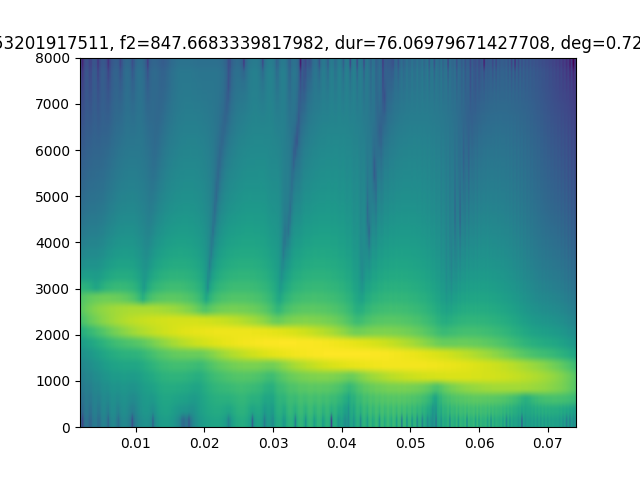

Max check freqs: 10
Max check freqs: 17


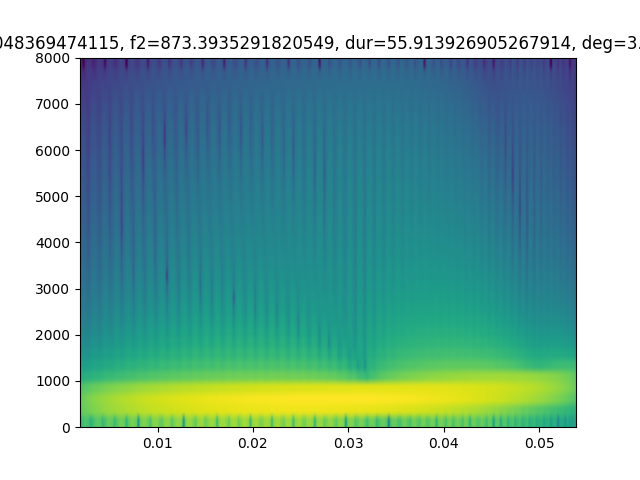

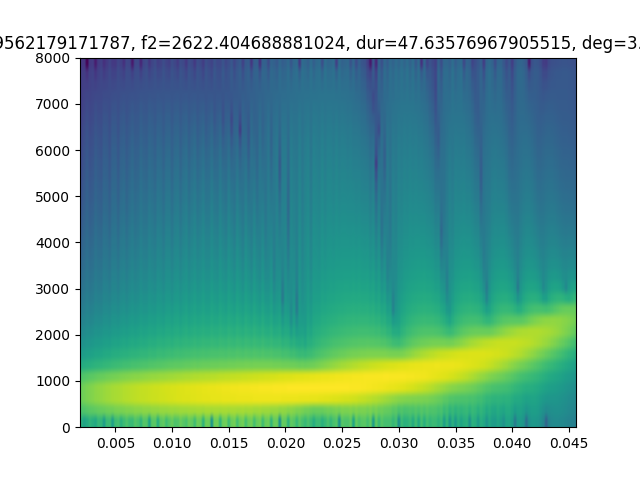

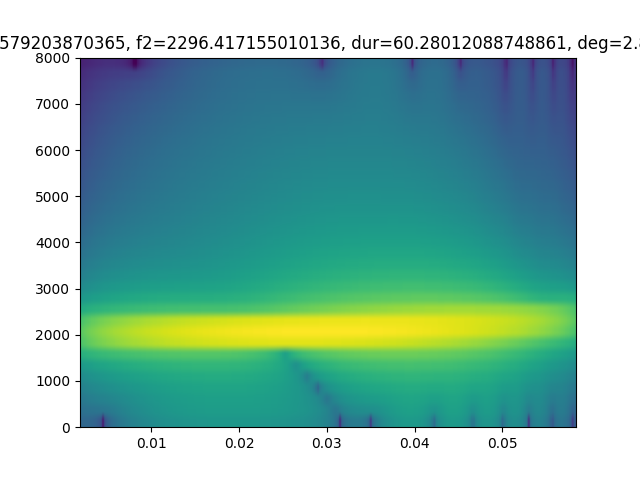

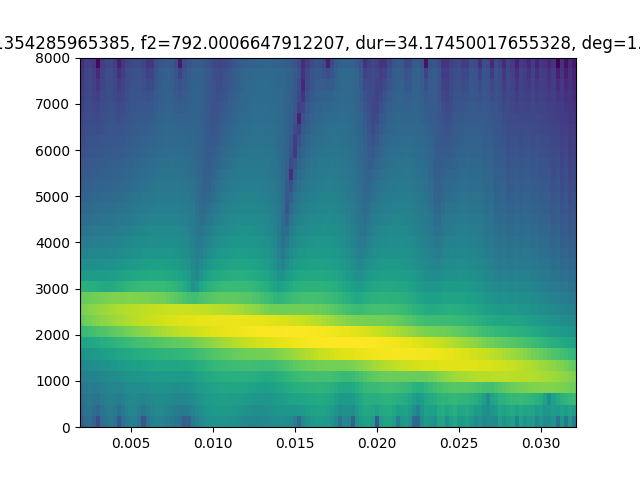

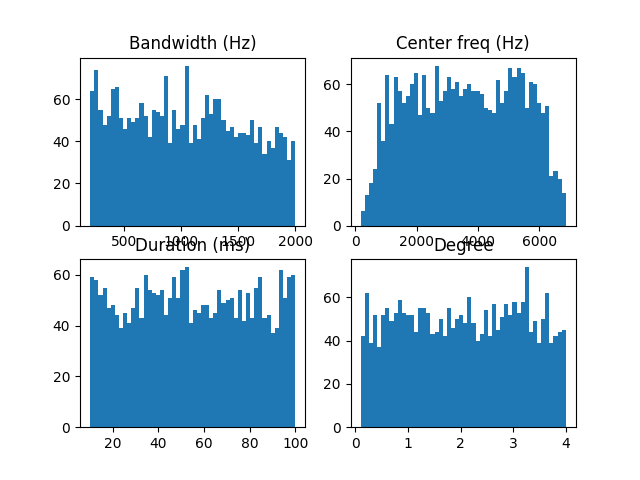

In [5]:
 # Test - pchirp()
plt.close('all')

N = 2500
MAX_BW = 2000
MIN_BW = 200
MAX_FREQ = 7000
MIN_FREQ = 50
MAX_DUR_MS = 100
MIN_DUR_MS = 10
MAX_DEGREE = 4
MIN_DEGREE = 0.1

def check_freqs(f1, f2):
    if np.abs(f1 - f2) < MIN_BW:
        return False
    if np.abs(f1 - f2) > MAX_BW:
        return False
    return True

def pick_val(lower_bnd, upper_bnd):
    return np.random.uniform(lower_bnd, upper_bnd)

def get_freqs():
    f1 = pick_val(MIN_FREQ, MAX_FREQ)
    f2 = pick_val(MIN_FREQ, MAX_FREQ)
    return (f1, f2)

def get_dur():
    return pick_val(MIN_DUR_MS, MAX_DUR_MS)

def get_degree():
    return pick_val(MIN_DEGREE, MAX_DEGREE)

exceptions = []
bw_all = np.zeros(N)
fc_all = np.zeros(N)
dur_all = np.zeros(N)
deg_all = np.zeros(N)
max_check_freqs = 0
exceptions = []
for i in range(N):
    # Pick freqs
    k = 0
    f1, f2 = get_freqs()
    while not check_freqs(f1, f2):
        f1, f2 = get_freqs()
        k += 1
    if k > max_check_freqs:
        max_check_freqs = k
        print(f"Max check freqs: {max_check_freqs}")

    # Pick duration ms
    dur = get_dur()

    # Pick degree
    deg = get_degree()

    # Fill in data
    bw_all[i] = np.abs(f2 - f1)
    fc_all[i] = (f1 + f2) / 2
    dur_all[i] = dur
    deg_all[i] = deg

    # Create chirplet
    try:
        chp = pchirp(f1, f2, dur, deg)

        if i % (N / 5) == 0:
            plt.figure()
            plt.specgram(chp, Fs=FS, NFFT=64, noverlap=60)            
            plt.title(f"i={i}, f1={f1}, f2={f2}, dur={dur}, deg={deg}")
            plt.show()
    except:
        print(f"Exception on interation {i}")
        exceptions.append(i)

# Plots
bins = 50
fig, ax = plt.subplots(2, 2)
ax[0,0].hist(bw_all, bins=bins)
ax[0,0].set_title('Bandwidth (Hz)')
ax[0,1].hist(fc_all, bins=bins)
ax[0,1].set_title('Center freq (Hz)')
ax[1,0].hist(dur_all, bins=bins)
ax[1,0].set_title('Duration (ms)')
ax[1,1].hist(deg_all, bins=bins)
ax[1,1].set_title('Degree')
plt.show()

## Findings: pchirp() tests

- Focus put initially on pchirp so as to limit scope reasonably: parameterized multi term chirplets will be revisited if promise shown with single term

- Since constraints are on bandwidth abs(f2 - f1) and center frequency (f1 + f2)/2, these will be parameterized for actual training rather than f1 and f2
    - chirp functions can still take frequencies as inputs, but they'll be computed from bandwidth and center frequency
    - this will reduce randomly generated frequency pairs that fail the check_freqs() test
    - 
- No parameter combinations caused exceptions with example constraints used here (these are realistic constraints)

- Many combinations produced minimal variance (in frequency), motivating another constraint that works logarithmically to ensure movement of frequency for the chirplet